# 03 · FunnyBirds + MCBM — does minimality fix grounding?

## The claim we test
MCBM ("There Was Never a Bottleneck in CBMs") argues the information bottleneck
makes each concept latent `z_j` a **minimal sufficient statistic** of its concept
label `c_j` — and that *this* is what makes concepts faithful. Loss:

$$\mathcal{L}= \mathrm{CE}(\hat y,y) + \lambda_c\,\mathrm{BCE}(z,c) + \gamma\cdot 0.2\cdot \overline{(q(z_j)-z_j)^2}$$

γ is the knob on minimality (**effective force = γ × 0.2**). We sweep γ ∈ {0,…,5}
(the paper's own range: CUB 0.05–0.3, synthetic 1–5).

## Our hypothesis (the refutation)
Minimality constrains what `z` **contains** ($I(z_j;x\mid c_j)=0$). Backwash is a
question of what `z` **reads** — which pixels. When the label is `c=f(class)`
(notebook 01: FunnyBirds concepts are species-constant), "encode only $c_j$" is
satisfiable by *class-lookup*. So tightening minimality should **not** remove
backwash. Prediction: the deletion-backwash curve is **flat (or rising) in γ**,
and MCBM ≈ CBM.

## Note on γ=0
γ=0 is MCBM **with no IB term** — a different head from vanilla CBM, *not* the CBM
baseline. The CBM number is drawn as a separate reference line.

*Reference (method source): `fb_mcbm_renderer_swap.ipynb`, `fb_mcbm_rl_renderer_swap.ipynb`
(§19 fwd/bwd grounding, §20 IB-compression-vs-grounding).*

In [1]:
import os, json, re, glob
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

CURATED = Path(os.environ["CURATED_DATA"])
REPO = Path.cwd().parent
import sys; sys.path.insert(0, str(REPO/"analysis"))
try:
    from plotting import set_paper_style, PALETTE; set_paper_style()
    CBM_C, MCBM_C = PALETTE["CBM"], PALETTE["MCBM"]
except Exception:
    CBM_C, MCBM_C = "#0072B2", "#D55E00"
plt.rcParams["figure.dpi"]=120

def parse_stem(stem):
    m = re.match(r"^funnybirds-(vanilla|cbm|mcbm)(?:-g([0-9p]+))?-s(\d+)$", stem)
    if not m: return None
    model, gtag, seed = m.group(1), m.group(2), int(m.group(3))
    gamma = float(gtag.replace("p",".")) if gtag else np.nan
    return model, gamma, seed

def need(p, how):
    ok = Path(p).exists()
    if not ok: print(f"[pending] {p}\n  produce it:  {how}")
    return ok


## 1 · Overall backwash vs γ  — the summary (and why it's diluted)
`backwash = retained P of a REMOVED part` (1 = fully backwashed, 0 = grounded),
averaged over all parts. This is the headline number, but averaging **hides** the
mechanism: 4 of 5 parts are ~0 and only tail is high, so the overall sits near
0.1 regardless. Section 2 is the one to show.

,model,gamma,seed,n,p_intact,p_removed,grounding,backwash
0,cbm,NaN,1,2500,0.999,0.085,0.915,0.085
1,mcbm,0.0,1,2500,0.997,0.115,0.885,0.115
2,mcbm,0.1,1,2500,0.998,0.095,0.905,0.095
3,mcbm,0.3,1,2500,0.997,0.108,0.892,0.108
4,mcbm,1.0,1,2500,0.998,0.093,0.907,0.093
5,mcbm,3.0,1,2500,NaN,NaN,NaN,NaN
6,mcbm,5.0,1,2500,0.997,0.112,0.887,0.113


MISSING/failed rows (re-run grounding): [('mcbm', 3.0)]


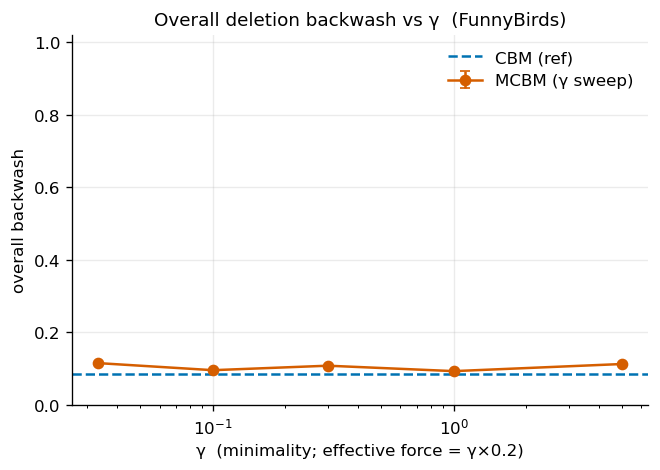

In [2]:
bw = CURATED/"backwash_vs_gamma.csv"
if need(bw, 'bash analysis/grounding_sweep.sh   (scores every checkpoint + collects)'):
    T = pd.read_csv(bw)
    display(T.round(3))
    mc = T[(T.model=="mcbm") & T.backwash.notna()].copy()
    cb = T[T.model=="cbm"]
    g = mc.groupby("gamma").backwash.agg(["mean","std"]).reset_index()
    floor = (g.gamma[g.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(6.2,4))
    ax.errorbar(g.gamma.replace(0,floor), g["mean"], yerr=g["std"].fillna(0),
                marker="o", capsize=3, color=MCBM_C, label="MCBM (γ sweep)")
    if len(cb): ax.axhline(cb.backwash.mean(), ls="--", color=CBM_C, label="CBM (ref)")
    ax.set_xscale("log"); ax.set_xlabel("γ  (minimality; effective force = γ×0.2)")
    ax.set_ylabel("overall backwash"); ax.set_ylim(0,1.02)
    ax.set_title("Overall deletion backwash vs γ  (FunnyBirds)"); ax.legend()
    miss = T[T.backwash.isna()]
    if len(miss): print("MISSING/failed rows (re-run grounding):",
                        list(zip(miss.model, miss.gamma)))

## 2 · Per-part backwash vs γ  — **the figure for the meeting**
Read the per-model grounding parquets directly and break backwash out **by part**.
tail is the backwash-prone part (most concept variants, most species-diagnostic —
notebook 02); wing/foot/beak/eye are grounded. The question is whether the tail
curve **comes down** as γ (minimality) increases.

tail backwash by γ:


,gamma,backwash
8,0.0,0.374
13,0.1,0.382
18,0.3,0.420
23,1.0,0.360
28,5.0,0.450


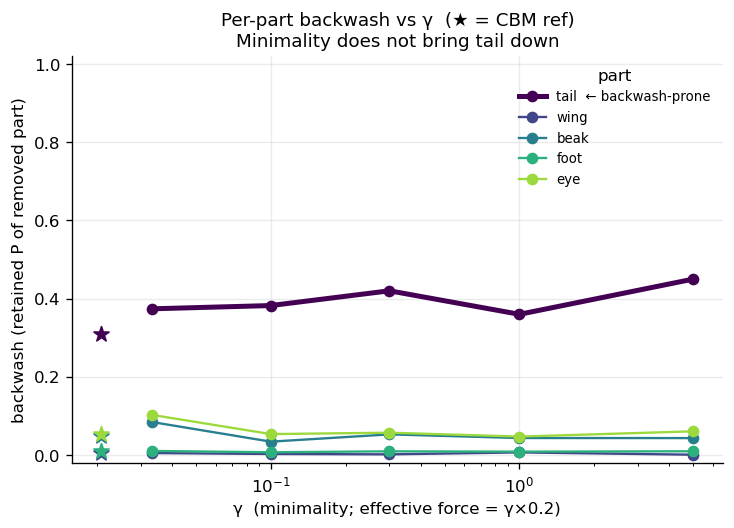

In [3]:
def per_part(f):
    d = pd.read_parquet(f)
    g = d.groupby("part").agg(pi=("p_intact","mean"), pr=("p_removed","mean"), n=("part","size"))
    g["backwash"] = 1 - (g.pi - g.pr)/g.pi
    return g["backwash"]

recs=[]
for f in sorted(glob.glob(str(CURATED/"grounding"/"funnybirds-*-s1.parquet"))):
    pr = parse_stem(Path(f).stem)
    if pr is None or pr[0]=="vanilla": continue
    model, gamma, seed = pr
    try: bwp = per_part(f)
    except Exception as e: print("skip", f, e); continue
    for part, v in bwp.items():
        recs.append(dict(model=model, gamma=gamma, part=part, backwash=float(v)))
P = pd.DataFrame(recs)
if len(P):
    parts = ["tail","wing","beak","foot","eye"]
    cbm_pp = P[P.model=="cbm"].set_index("part").backwash
    mc = P[(P.model=="mcbm") & P.backwash.notna()]
    floor = (mc.gamma[mc.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(7,4.4))
    cmap = plt.cm.viridis(np.linspace(0,0.85,len(parts)))
    for part,col in zip(parts,cmap):
        s = mc[mc.part==part].sort_values("gamma")
        if not len(s): continue
        lw = 3 if part=="tail" else 1.4
        ax.plot(s.gamma.replace(0,floor), s.backwash, "o-", color=col, lw=lw,
                label=f"{part}"+("  ← backwash-prone" if part=="tail" else ""))
        if part in cbm_pp.index:
            ax.scatter([floor/1.6],[cbm_pp[part]], marker="*", s=90, color=col, zorder=5)
    ax.set_xscale("log"); ax.set_xlabel("γ  (minimality; effective force = γ×0.2)")
    ax.set_ylabel("backwash (retained P of removed part)"); ax.set_ylim(-0.02,1.02)
    ax.set_title("Per-part backwash vs γ  (★ = CBM ref)\nMinimality does not bring tail down")
    ax.legend(title="part", fontsize=8)
    print("tail backwash by γ:")
    display(mc[mc.part=='tail'][['gamma','backwash']].sort_values('gamma').round(3))
else:
    print("[pending] no grounding parquets -> bash analysis/grounding_sweep.sh")

## 3 · Species-code vs γ  — did the class channel survive compression?
The mechanism metric (notebook 02): how well a linear probe recovers **species**
from the reported concept vector. If `species←c_preds` stays ≈1 as γ grows,
minimality compressed the representation *without cutting the class channel* — a
minimal sufficient statistic of a class-derived label is still a class code.

In [4]:
rows=[]
for f in sorted(glob.glob(str(CURATED/"species_probe"/"funnybirds-mcbm-g*-s1.json"))):
    m=re.search(r"-g([0-9p]+)-s", Path(f).name)
    if not m: continue
    S=json.loads(Path(f).read_text())
    rows.append(dict(gamma=float(m.group(1).replace("p",".")),
                     z=S["species_from_z"]["acc"], c=S["species_from_cpreds"]["acc"],
                     tail=S["species_from_part_cpreds"].get("tail",{}).get("acc",np.nan),
                     chance=S["chance"]))
cbj = CURATED/"species_probe"/"funnybirds-cbm-s1.json"
if rows:
    D=pd.DataFrame(rows).sort_values("gamma"); display(D.round(3))
    floor=(D.gamma[D.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(figsize=(6.2,4))
    ax.plot(D.gamma.replace(0,floor), D.c, "o-", color=MCBM_C, label="species←c_preds (all concepts)")
    ax.plot(D.gamma.replace(0,floor), D.tail,"s--", color="#5B8C5A", label="species←tail concepts only")
    if cbj.exists():
        Sc=json.loads(cbj.read_text()); ax.axhline(Sc["species_from_cpreds"]["acc"], ls=":", color=CBM_C, label="CBM species←c_preds")
    ax.axhline(D.chance.iloc[0], ls=":", color="k", label="chance (1/50)")
    ax.set_xscale("log"); ax.set_xlabel("γ"); ax.set_ylabel("species recoverable"); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
    ax.set_title("Class channel survives minimality (species stays recoverable)")
else:
    print("[pending] no MCBM species_probe json -> grounding_sweep.sh runs the probe too")

[pending] no MCBM species_probe json -> grounding_sweep.sh runs the probe too


## 4 · CONTROL — did γ actually tighten the bottleneck?
Flat backwash only refutes minimality **if γ changed the representation**. The
minimality term is `γ·0.2·mean((6c−3 − z)²)` — it pulls each `z_j` toward the
±3 target set by the concept label. We read `z` straight from the saved held-out
predictions and measure whether the code is genuinely being pinned to ±3 as γ
grows (the term the sweep optimizes), plus fit quality.

- **`mean((±3−z)²)` ↓ and `mean|z|` ↑ with γ** ⇒ γ *did* bite → flat backwash is a
  real refutation (minimality tightened, grounding didn't move).
- **All flat** ⇒ γ range too weak to exercise minimality → widen it before concluding.

*(Also note: backwash above is a ratio of concept probabilities, which sharpen as
z saturates — a mild confound. The z-margin version is the robustness check.)*

/tmp/tmp.QS8p6ZNYUF/ipykernel_1160284/893770996.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  d = torch.load(pth, map_location="cpu")


,gamma,rep_loss,mean_abs_z,task_acc,concept_acc
0,0.0,458.125,18.408,0.745,0.993
1,0.1,1.892,3.232,0.754,0.995
2,0.3,0.273,3.108,0.752,0.995
3,1.0,0.185,3.079,0.744,0.995
4,5.0,0.150,3.025,0.748,0.995


VERDICT: γ moved the representation (minimality tightened) -> flat backwash is a real refutation


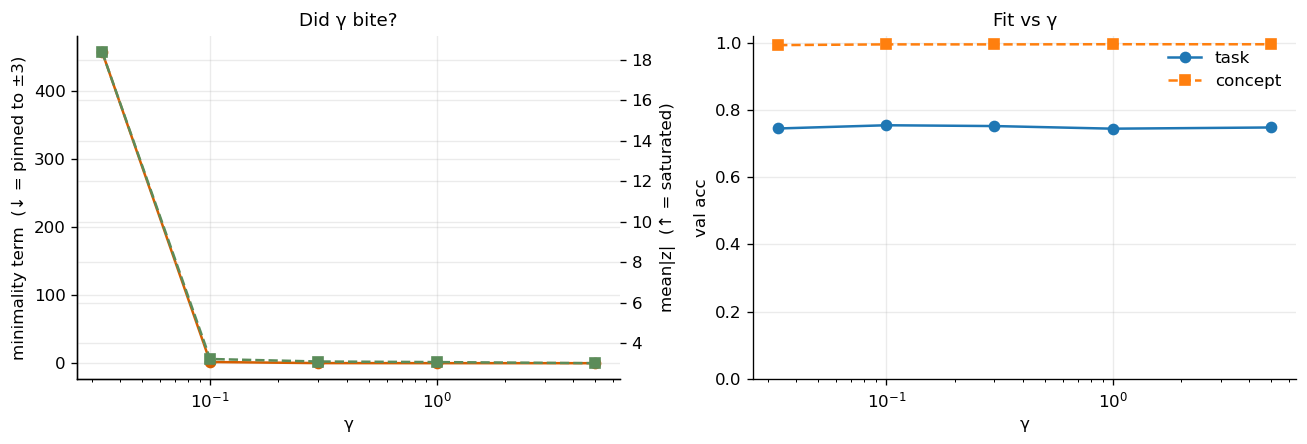

In [5]:
import torch
def zstats(cfg):
    pth = REPO/"external"/"minimal_cbm"/"results"/cfg/"1"/"predictions"/"epoch_100.pth"
    if not pth.exists(): return None
    d = torch.load(pth, map_location="cpu")
    z, c = d["z"].float(), d["c"].float()
    if not (np.isfinite(z).all() and np.isfinite(c).all()):
        return None            # diverged checkpoint (NaN) -> skip
    rep = float(((6*c - 3 - z)**2).mean())          # the γ-weighted minimality term
    sat = float(z.abs().mean())                     # saturation of the code
    yp  = d["y_preds"]; ta = float((yp.argmax(-1)==d["y"]).float().mean()) if yp.ndim>1 else float((yp==d["y"]).float().mean())
    cp  = d["c_preds"]; cp = cp[...,0] if cp.ndim==3 else cp
    ca  = float(((cp>=0.5).float()==c).float().mean())
    return rep, sat, ta, ca

rows=[]
for g,tag in [(0,"g0"),(0.1,"g0p1"),(0.3,"g0p3"),(1,"g1"),(3,"g3"),(5,"g5")]:
    s = zstats(f"funnybirds-mcbm-{tag}")
    if s: rows.append((g,*s))
if rows:
    D = pd.DataFrame(rows, columns=["gamma","rep_loss","mean_abs_z","task_acc","concept_acc"])
    display(D.round(3))
    floor=(D.gamma[D.gamma>0].min() or 0.05)/3
    fig,ax=plt.subplots(1,2,figsize=(11,3.8))
    ax[0].plot(D.gamma.replace(0,floor), D.rep_loss, "o-", color=MCBM_C, label="mean (±3−z)²")
    ax0b=ax[0].twinx(); ax0b.plot(D.gamma.replace(0,floor), D.mean_abs_z, "s--", color="#5B8C5A", label="mean|z|")
    ax[0].set_xscale("log"); ax[0].set_xlabel("γ"); ax[0].set_ylabel("minimality term  (↓ = pinned to ±3)")
    ax0b.set_ylabel("mean|z|  (↑ = saturated)"); ax[0].set_title("Did γ bite?")
    ax[1].plot(D.gamma.replace(0,floor), D.task_acc, "o-", label="task"); ax[1].plot(D.gamma.replace(0,floor), D.concept_acc, "s--", label="concept")
    ax[1].set_xscale("log"); ax[1].set_xlabel("γ"); ax[1].set_ylabel("val acc"); ax[1].set_ylim(0,1.02); ax[1].legend(); ax[1].set_title("Fit vs γ")
    plt.tight_layout()
    moved = (D.rep_loss.max()-D.rep_loss.min()) > 0.05*max(D.rep_loss.max(),1e-9) or (D.mean_abs_z.max()-D.mean_abs_z.min())>0.1
    print("VERDICT:", "γ moved the representation (minimality tightened) -> flat backwash is a real refutation"
          if moved else "γ barely moved the representation -> sweep underpowered; WIDEN γ before concluding")
else:
    print("[pending] need results/funnybirds-mcbm-g*/1/predictions/epoch_100.pth")
    print("  (saved only if the trainer ran with save=True; otherwise re-eval to dump z)")

## Takeaway (for the slide)
- **Overall backwash is flat in γ** (~0.09–0.12) and **MCBM ≈ CBM** — tightening the
  information bottleneck does **not** reduce backwash.
- **The tail concept stays backwashed at every γ**: its concept is retained when the
  tail is deleted regardless of minimality strength. wing/foot/beak/eye stay grounded.
- **Species remains recoverable from the concepts across γ** — minimality compressed
  *content* but left the *class channel* intact.

**Interpretation.** Minimality (a constraint on what `z` contains) is orthogonal to
backwash (a constraint on what `z` reads). When `c = f(class)`, a minimal sufficient
statistic of `c` is still a class code — so MCBM inherits CBM's backwash.
*Single seed (s1); error bars need seed replication before locking. γ=3 grounding
failed (NaN) — re-run that one checkpoint.*